In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as sp_stats

plt.rcParams['svg.fonttype'] = 'none'

In [3]:
construct_stats = pd.read_csv('constructs_df.csv', index_col=0)
raw_data = pd.read_csv('cells_concat_raw.csv', index_col=0)

construct_stats['construct'] = construct_stats['construct'].astype(str)
# ensure construct values are integer-like (4.0 -> 4) and stored as strings to match construct_stats
if 'construct' in raw_data.columns:
    raw_data['construct'] = raw_data['construct'].astype(float).astype(int).astype(str)
else:
    raw_data['construct'] = raw_data.index.astype(float).astype(int).astype(str)

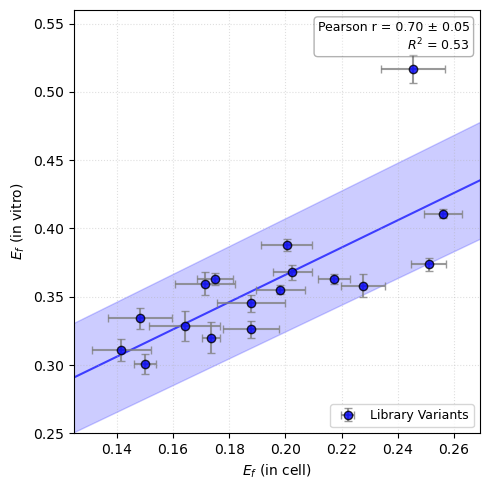

In [11]:
# plot Ef_cell vs Ef_invitro_mean_basal_b with error bars - BLUE POINTS ONLY
# WITH MONTE CARLO PEARSON CALCULATION
mask = construct_stats[['Ef_cell', 'Ef_cell_std', 'Ef_invitro_mean_basal_b', 'Ef_invitro_std_basal_b']].notnull().all(axis=1)
plot_df = construct_stats.loc[mask].copy()

# Filter out GS constructs
plot_df['is_GS'] = plot_df['construct'].astype(str).str.contains('GS', na=False)
plot_df = plot_df[~plot_df['is_GS']]

x = plot_df['Ef_cell']
y = plot_df['Ef_invitro_mean_basal_b']
xerr = plot_df['Ef_cell_std']
yerr = plot_df['Ef_invitro_std_basal_b']

# Monte Carlo sampling for Pearson correlation
n_iterations = 1000
pearson_values = []

for _ in range(n_iterations):
    sampled_x = []
    sampled_y = []
    
    for idx, row in plot_df.iterrows():
        # Sample from normal distributions based on mean and std for each construct
        sampled_x_val = np.random.normal(row['Ef_cell'], row['Ef_cell_std'])
        sampled_y_val = np.random.normal(row['Ef_invitro_mean_basal_b'], row['Ef_invitro_std_basal_b'])

        sampled_x.append(sampled_x_val)
        sampled_y.append(sampled_y_val)
    
    # Calculate Pearson correlation across all constructs for this iteration
    if len(sampled_x) == len(plot_df):  # Ensure we have all constructs
        pearson_r_sample, _ = sp_stats.pearsonr(sampled_x, sampled_y)
        pearson_values.append(pearson_r_sample)

# Calculate mean and std of Pearson correlations
pearson_r_mean = np.mean(pearson_values)
pearson_r_std = np.std(pearson_values)

fig, ax = plt.subplots(figsize=(5, 5))

# Plot blue points
ax.errorbar(x, y, xerr=xerr, yerr=yerr, 
            fmt='o', color='blue', markeredgecolor='black', markeredgewidth=1,
            ecolor='grey', capsize=3, alpha=0.8, barsabove=False, label='Library Variants')

# Linear regression for line of best fit
slope, intercept, r_value, p_value, std_err = sp_stats.linregress(x, y)

# Get x-axis limits to extend line to full width
x_limits = ax.get_xlim()
line_x = np.array(x_limits)
line_y = slope * line_x + intercept

# Plot line of best fit
ax.plot(line_x, line_y, color='blue', linestyle='-', linewidth=1.5, alpha=0.7, zorder=1)

# Calculate 95% confidence interval
n = len(x)
dof = n - 2
t_val = sp_stats.t.ppf(0.975, dof)
x_mean = np.mean(x)
sxx = np.sum((x - x_mean)**2)
predict_y = slope * x + intercept
residuals = y - predict_y
s_resid = np.sqrt(np.sum(residuals**2) / dof)
se_line = s_resid * np.sqrt(1/n + (line_x - x_mean)**2 / sxx)
margin = t_val * se_line

# Shade prediction interval
ax.fill_between(line_x, line_y - margin, line_y + margin,
                color='blue', alpha=0.2, zorder=0)

ax.set_xlabel('$E_{f}$ (in cell)')
ax.set_ylabel('$E_{f}$ (in vitro)')
ax.grid(True, linestyle=':', alpha=0.4)

# Add legend
ax.legend(loc='lower right', frameon=True, fontsize=9)

# Add Monte Carlo Pearson correlation text with 95% CI
ax.text(0.975, 0.975, f'Pearson r = {pearson_r_mean:.2f} ± {pearson_r_std:.2f}\n$R^2$ = {r_value**2:.2f}', 
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.3))

plt.xlim(x_limits[0], x_limits[1])
plt.ylim(.25, .56)
plt.tight_layout()
#plt.savefig('Figure_graphs/Fig2/Ef_cell_vs_Ef_invitro_monte_carlo.svg')

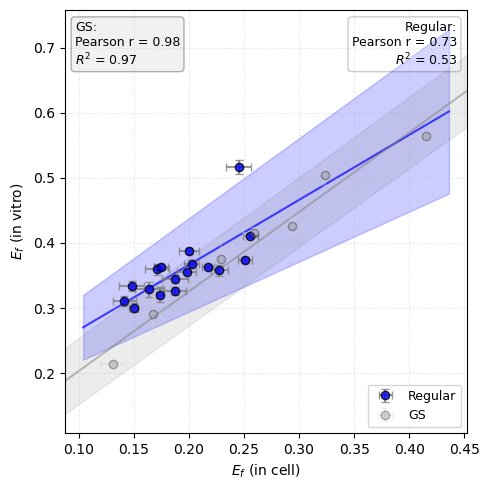

In [3]:
# plot Ef_cell vs Ef_invitro_mean_basal with error bars - BLUE for regular, GREY for GS
mask = df[['Ef_cell', 'Ef_cell_std', 'Ef_invitro_mean_basal_b', 'Ef_invitro_std_basal_b']].notnull().all(axis=1)
plot_df = df.loc[mask].copy()

# Separate regular and GS constructs
plot_df['is_GS'] = plot_df['construct'].str.contains('GS', na=False)
regular_mask = ~plot_df['is_GS']
gs_mask = plot_df['is_GS']

regular_df = plot_df[regular_mask]
gs_df = plot_df[gs_mask]

fig, ax = plt.subplots(figsize=(5, 5))

# Plot regular points in blue
if len(regular_df) > 0:
    ax.errorbar(regular_df['Ef_cell'], regular_df['Ef_invitro_mean_basal_b'], 
                xerr=regular_df['Ef_cell_std'], yerr=regular_df['Ef_invitro_std_basal_b'],
                fmt='o', color='blue', markeredgecolor='black', markeredgewidth=1,
                ecolor='grey', capsize=3, alpha=0.8, barsabove=False, label='Regular')

# Plot GS points in grey with low alpha
if len(gs_df) > 0:
    ax.errorbar(gs_df['Ef_cell'], gs_df['Ef_invitro_mean_basal_b'],
                xerr=gs_df['Ef_cell_std'], yerr=gs_df['Ef_invitro_std_basal_b'],
                fmt='o', color='grey', markeredgecolor='black', markeredgewidth=1,
                ecolor='lightgrey', capsize=3, alpha=0.3, barsabove=False, label='GS')

# Linear regression for REGULAR constructs
if len(regular_df) > 1:
    x_regular = regular_df['Ef_cell']
    y_regular = regular_df['Ef_invitro_mean_basal_b']
    
    slope_reg, intercept_reg, r_value_reg, p_value_reg, std_err_reg = sp_stats.linregress(x_regular, y_regular)
    pearson_r_reg, pearson_p_reg = sp_stats.pearsonr(x_regular, y_regular)
    
    x_limits = ax.get_xlim()
    line_x_reg = np.array(x_limits)
    line_y_reg = slope_reg * line_x_reg + intercept_reg
    
    ax.plot(line_x_reg, line_y_reg, color='blue', linestyle='-', linewidth=1.5, alpha=0.7, zorder=1)
    
    # Calculate 95% confidence interval for regular
    n_reg = len(x_regular)
    dof_reg = n_reg - 2
    t_val_reg = sp_stats.t.ppf(0.975, dof_reg)
    x_mean_reg = np.mean(x_regular)
    sxx_reg = np.sum((x_regular - x_mean_reg)**2)
    predict_y_reg = slope_reg * x_regular + intercept_reg
    residuals_reg = y_regular - predict_y_reg
    s_resid_reg = np.sqrt(np.sum(residuals_reg**2) / dof_reg)
    se_line_reg = s_resid_reg * np.sqrt(1/n_reg + (line_x_reg - x_mean_reg)**2 / sxx_reg)
    margin_reg = t_val_reg * se_line_reg
    
    ax.fill_between(line_x_reg, line_y_reg - margin_reg, line_y_reg + margin_reg,
                    color='blue', alpha=0.2, zorder=0)

# Linear regression for GS constructs
if len(gs_df) > 1:
    x_gs = gs_df['Ef_cell']
    y_gs = gs_df['Ef_invitro_mean_basal_b']
    
    slope_gs, intercept_gs, r_value_gs, p_value_gs, std_err_gs = sp_stats.linregress(x_gs, y_gs)
    pearson_r_gs, pearson_p_gs = sp_stats.pearsonr(x_gs, y_gs)
    
    x_limits = ax.get_xlim()
    line_x_gs = np.array(x_limits)
    line_y_gs = slope_gs * line_x_gs + intercept_gs
    
    ax.plot(line_x_gs, line_y_gs, color='grey', linestyle='-', linewidth=1.5, alpha=0.5, zorder=1)
    
    # Calculate 95% confidence interval for GS
    n_gs = len(x_gs)
    dof_gs = n_gs - 2
    t_val_gs = sp_stats.t.ppf(0.975, dof_gs)
    x_mean_gs = np.mean(x_gs)
    sxx_gs = np.sum((x_gs - x_mean_gs)**2)
    predict_y_gs = slope_gs * x_gs + intercept_gs
    residuals_gs = y_gs - predict_y_gs
    s_resid_gs = np.sqrt(np.sum(residuals_gs**2) / dof_gs)
    se_line_gs = s_resid_gs * np.sqrt(1/n_gs + (line_x_gs - x_mean_gs)**2 / sxx_gs)
    margin_gs = t_val_gs * se_line_gs
    
    ax.fill_between(line_x_gs, line_y_gs - margin_gs, line_y_gs + margin_gs,
                    color='grey', alpha=0.15, zorder=0)

ax.set_xlabel('$E_{f}$ (in cell)')
ax.set_ylabel('$E_{f}$ (in vitro)')
ax.grid(True, linestyle=':', alpha=0.4)

# Add statistics text for regular constructs
if len(regular_df) > 1:
    ax.text(0.975, 0.975, f'Regular:\nPearson r = {pearson_r_reg:.2f}\n$R^2$ = {r_value_reg**2:.2f}', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top', 
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.2))

# Add statistics text for GS constructs if present
if len(gs_df) > 1:
    ax.text(0.025, 0.975, f'GS:\nPearson r = {pearson_r_gs:.2f}\n$R^2$ = {r_value_gs**2:.2f}', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top', 
            horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='lightgrey', alpha=0.3))

ax.legend(loc='lower right', frameon=True, fontsize=9)

plt.xlim(x_limits[0], x_limits[1])
plt.tight_layout()
#plt.savefig('Figure_graphs/Fig2/Ef_cell_vs_Ef_invitro_all_blue.svg')

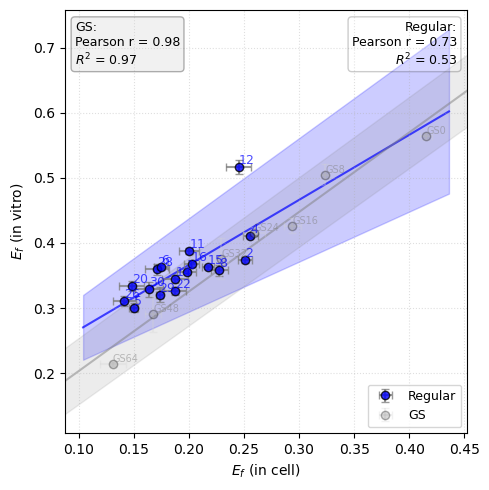

In [6]:
# plot Ef_cell vs Ef_invitro_mean_basal with error bars - BLUE for regular, GREY for GS
mask = df[['Ef_cell', 'Ef_cell_std', 'Ef_invitro_mean_basal_b', 'Ef_invitro_std_basal_b']].notnull().all(axis=1)
plot_df = df.loc[mask].copy()

# Separate regular and GS constructs
plot_df['is_GS'] = plot_df['construct'].str.contains('GS', na=False)
regular_mask = ~plot_df['is_GS']
gs_mask = plot_df['is_GS']

regular_df = plot_df[regular_mask]
gs_df = plot_df[gs_mask]

fig, ax = plt.subplots(figsize=(5, 5))

# Plot regular points in blue
if len(regular_df) > 0:
    ax.errorbar(regular_df['Ef_cell'], regular_df['Ef_invitro_mean_basal_b'], 
                xerr=regular_df['Ef_cell_std'], yerr=regular_df['Ef_invitro_std_basal_b'],
                fmt='o', color='blue', markeredgecolor='black', markeredgewidth=1,
                ecolor='grey', capsize=3, alpha=0.8, barsabove=False, label='Regular')
    
    # Add labels to regular points
    for idx, row in regular_df.iterrows():
        ax.text(row['Ef_cell'], row['Ef_invitro_mean_basal_b'], 
                row['construct'], fontsize=9, alpha=0.7, 
                ha='left', va='bottom', color='blue')

# Plot GS points in grey with low alpha
if len(gs_df) > 0:
    ax.errorbar(gs_df['Ef_cell'], gs_df['Ef_invitro_mean_basal_b'],
                xerr=gs_df['Ef_cell_std'], yerr=gs_df['Ef_invitro_std_basal_b'],
                fmt='o', color='grey', markeredgecolor='black', markeredgewidth=1,
                ecolor='lightgrey', capsize=3, alpha=0.3, barsabove=False, label='GS')
    
    # Add labels to GS points
    for idx, row in gs_df.iterrows():
        ax.text(row['Ef_cell'], row['Ef_invitro_mean_basal_b'], 
                row['construct'], fontsize=7, alpha=0.5, 
                ha='left', va='bottom', color='grey')

# Linear regression for REGULAR constructs
if len(regular_df) > 1:
    x_regular = regular_df['Ef_cell']
    y_regular = regular_df['Ef_invitro_mean_basal_b']
    
    slope_reg, intercept_reg, r_value_reg, p_value_reg, std_err_reg = sp_stats.linregress(x_regular, y_regular)
    pearson_r_reg, pearson_p_reg = sp_stats.pearsonr(x_regular, y_regular)
    
    x_limits = ax.get_xlim()
    line_x_reg = np.array(x_limits)
    line_y_reg = slope_reg * line_x_reg + intercept_reg
    
    ax.plot(line_x_reg, line_y_reg, color='blue', linestyle='-', linewidth=1.5, alpha=0.7, zorder=1)
    
    # Calculate 95% confidence interval for regular
    n_reg = len(x_regular)
    dof_reg = n_reg - 2
    t_val_reg = sp_stats.t.ppf(0.975, dof_reg)
    x_mean_reg = np.mean(x_regular)
    sxx_reg = np.sum((x_regular - x_mean_reg)**2)
    predict_y_reg = slope_reg * x_regular + intercept_reg
    residuals_reg = y_regular - predict_y_reg
    s_resid_reg = np.sqrt(np.sum(residuals_reg**2) / dof_reg)
    se_line_reg = s_resid_reg * np.sqrt(1/n_reg + (line_x_reg - x_mean_reg)**2 / sxx_reg)
    margin_reg = t_val_reg * se_line_reg
    
    ax.fill_between(line_x_reg, line_y_reg - margin_reg, line_y_reg + margin_reg,
                    color='blue', alpha=0.2, zorder=0)

# Linear regression for GS constructs
if len(gs_df) > 1:
    x_gs = gs_df['Ef_cell']
    y_gs = gs_df['Ef_invitro_mean_basal_b']
    
    slope_gs, intercept_gs, r_value_gs, p_value_gs, std_err_gs = sp_stats.linregress(x_gs, y_gs)
    pearson_r_gs, pearson_p_gs = sp_stats.pearsonr(x_gs, y_gs)
    
    x_limits = ax.get_xlim()
    line_x_gs = np.array(x_limits)
    line_y_gs = slope_gs * line_x_gs + intercept_gs
    
    ax.plot(line_x_gs, line_y_gs, color='grey', linestyle='-', linewidth=1.5, alpha=0.5, zorder=1)
    
    # Calculate 95% confidence interval for GS
    n_gs = len(x_gs)
    dof_gs = n_gs - 2
    t_val_gs = sp_stats.t.ppf(0.975, dof_gs)
    x_mean_gs = np.mean(x_gs)
    sxx_gs = np.sum((x_gs - x_mean_gs)**2)
    predict_y_gs = slope_gs * x_gs + intercept_gs
    residuals_gs = y_gs - predict_y_gs
    s_resid_gs = np.sqrt(np.sum(residuals_gs**2) / dof_gs)
    se_line_gs = s_resid_gs * np.sqrt(1/n_gs + (line_x_gs - x_mean_gs)**2 / sxx_gs)
    margin_gs = t_val_gs * se_line_gs
    
    ax.fill_between(line_x_gs, line_y_gs - margin_gs, line_y_gs + margin_gs,
                    color='grey', alpha=0.15, zorder=0)

ax.set_xlabel('$E_{f}$ (in cell)')
ax.set_ylabel('$E_{f}$ (in vitro)')
ax.grid(True, linestyle=':', alpha=0.4)

# Add statistics text for regular constructs
if len(regular_df) > 1:
    ax.text(0.975, 0.975, f'Regular:\nPearson r = {pearson_r_reg:.2f}\n$R^2$ = {r_value_reg**2:.2f}', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top', 
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.2))

# Add statistics text for GS constructs if present
if len(gs_df) > 1:
    ax.text(0.025, 0.975, f'GS:\nPearson r = {pearson_r_gs:.2f}\n$R^2$ = {r_value_gs**2:.2f}', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top', 
            horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='lightgrey', alpha=0.3))

ax.legend(loc='lower right', frameon=True, fontsize=9)

plt.xlim(x_limits[0], x_limits[1])
plt.tight_layout()
#plt.savefig('Figure_graphs/Fig2/Ef_cell_vs_Ef_invitro_all_blue.svg')